In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from numpy import linalg as la
from scipy.optimize import curve_fit

df = pd.read_csv('../data/game_data.csv')
g = np.array(df['Most Popular Game Genre'])
h = np.array(df['Play Hours'])
a = np.array(df['Player Age'])

# This calculation creates a Numpy array of hours per age
hours_per_age = h/a

print("The average play time for: ")
for games,age,time in zip(g,a,h):
    print(f"{games} is {time} hours at age {age}")

The average play time for: 
Action is 523 hours at age 22
RPG is 214 hours at age 35
Shooter is 742 hours at age 28
Sports is 56 hours at age 19
Puzzle is 310 hours at age 24
Adventure is 789 hours at age 30
Strategy is 431 hours at age 27
Shooter is 102 hours at age 21
Action is 670 hours at age 32
RPG is 248 hours at age 25
Sports is 900 hours at age 40
Puzzle is 134 hours at age 18
Action is 312 hours at age 23
Adventure is 578 hours at age 31
Shooter is 421 hours at age 29
RPG is 87 hours at age 16
Strategy is 600 hours at age 34
Puzzle is 499 hours at age 26
Sports is 305 hours at age 20
Action is 719 hours at age 33
Adventure is 412 hours at age 28
Shooter is 254 hours at age 22
RPG is 623 hours at age 36
Puzzle is 188 hours at age 19
Strategy is 730 hours at age 38
Sports is 365 hours at age 27
Action is 485 hours at age 24
Adventure is 216 hours at age 21
Shooter is 699 hours at age 31
RPG is 112 hours at age 17
Puzzle is 845 hours at age 39
Action is 391 hours at age 23
Strate

Create Scatter Plot

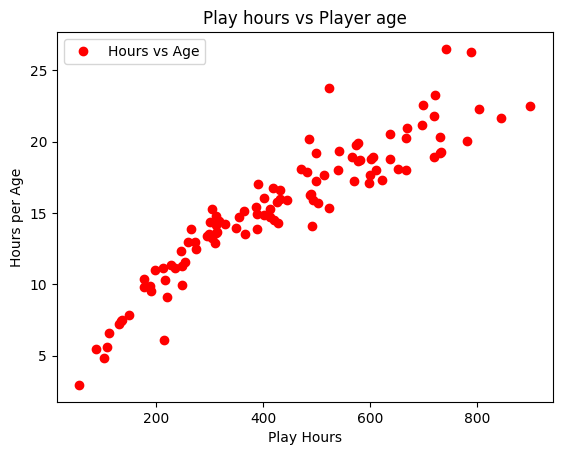

In [38]:
fig,ax = plt.subplots();
scatt_plot, = ax.plot(h,hours_per_age,"ro",label="Hours vs Age");
ax.set_title("Play hours vs Player age");
ax.set_xlabel('Play Hours')
ax.set_ylabel('Hours per Age')
ax.legend()

Interpretation:

Positive trend: More total play hours → higher hours per age

Flattening curve: Some players reach a limit in “intensity”

Scatter width: Variability in player ages for the same number of play hours

Adding Curves to the Scatter Plot

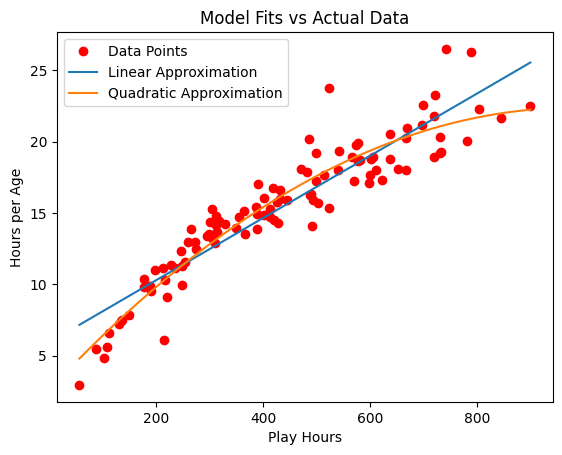

In [40]:
# These create function representing arbitray linear and quadratic functions
def arb_linear(x,a,b): return a*x+b
def arb_quad(x,a,b,c): return a*x**2+b*x+c

# try to uncomment and complete this function for an arbitray exponential y=b*e^(ax)
def arb_exp(x,a,b): return b * np.exp(a * x)

# how would you use the arbitrary exponential function you created to get coefficients?
# x -> independ variables
# a, b -> coeffiecients to be fitted
# arb_exp(x,a,b) returns predicted hours_per_age
# use curve_fit to get the coefficients


# Fit curves
lcoef, lcovar = curve_fit(arb_linear, h, hours_per_age)
qcoef, qcovar = curve_fit(arb_quad, h, hours_per_age)

# ecoef, ecovar = curve_fit(arb_exp, h, hours_per_age)

# Plot
fig, ax = plt.subplots()

# scatter plot of data
ax.plot(h, hours_per_age, "ro", label="Data Points")

# line space for smooth curves
x = np.linspace(min(h), max(h), 300)

# curves
ax.plot(x, arb_linear(x, *lcoef), label="Linear Approximation")
ax.plot(x, arb_quad(x, *qcoef), label="Quadratic Approximation")
# ax.plot(x, arb_exp(x, *ecoef), label="Exponential Approximation")

ax.set_xlabel("Play Hours")
ax.set_ylabel("Hours per Age")
ax.set_title("Model Fits vs Actual Data")
ax.legend()

plt.show()

Linear Algebra

Here we look at the sort of calculations that are going on in the background.  We can see that if we apply the linear regression techniques we learned in class we get the same coeficients as

In [16]:
# Create a matrix of x values including a column ones for the constant term
r, = h.shape
A = np.column_stack([h,np.ones(r)])

# Calculate A^TA for regression
M = A.transpose()@A

# Find the inverse of A^TA
Minv = la.inv(M)

# The coefficeints are (A^TA)^-1A^Tb where b is the vector of y values
manuel = Minv@A.transpose()@hours_per_age

print(manuel)

# We can see that our result matches SciPy's output
lcoef


[0.02178415 5.9405843 ]


array([0.02178415, 5.9405843 ])

Quadratic Approximations


In [18]:
# We can repeat the above stpes, with a slightly differnt matrix, to get 
# coefficients for a quadratic approximation
B = np.column_stack([h**2,h,np.ones(r)])
N = B.transpose()@B
Ninv = la.inv(N)
manuelQuad = Ninv@B.transpose()@hours_per_age

print(manuelQuad)

# Again the results match SciPy
qcoef

[-2.03931181e-05  4.01621155e-02  2.61015433e+00]


array([-2.03931181e-05,  4.01621155e-02,  2.61015433e+00])

Mystery Curve
What type of general curves are being fit to the data in these examples?

A power-law model and an exponential model.

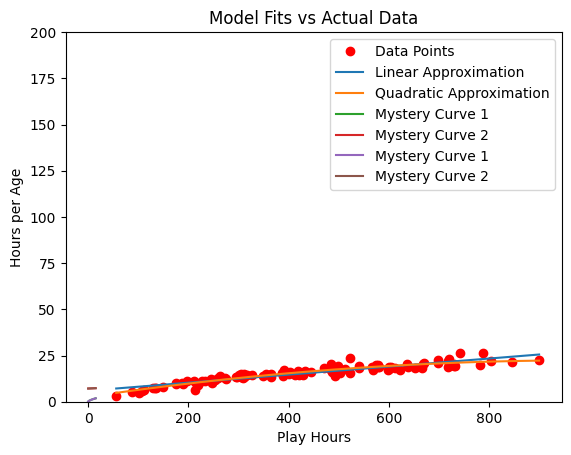

In [ ]:
C = np.column_stack([np.log(h),np.ones(r)])
ar,lnbr=la.inv(C.T@C)@C.T@np.log(hours_per_age)
br = np.e**lnbr

ae,lnbe = Minv@A.T@np.log(hours_per_age)
be = np.e**lnbe

X = np.linspace(0.1,15)

Yr = br*X**ar
Ye = be*np.e**(ae*X)

Mystery1, = ax.plot(X,Yr,label="Mystery Curve 1");
Mystery2, = ax.plot(X,Ye,label="Mystery Curve 2");
ax.set_ylim(0,200)
ax.legend()
fig

The graph above is looking kind of crowded.  Below are two different ways to clean it up.  What is the difference between the two approaches? What might be the advantages or disadvantages of each approach?

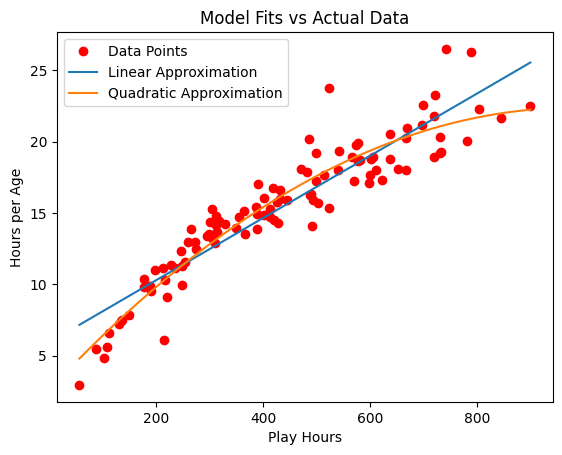

In [34]:
# linearApprox.remove()
quadApprox.set_visible(False)
ax.legend()
fig

1. # linearApprox.remove() -
 This completely removes the line object.
 After calling .remove() the line no longer exists in the figure or in the legend
 
 Advantage: Cleans up the space entirely,
 
 Disadvantage: You cannot toggle it back on - the line is gone unless you replot it

 2. # quadApprox.set_visible(False) -
 This hides the line without removing it
 The object still exists in the axes; it's just not drawn
 
 Advantage: 
 Flexible - Can hide/show lines dynamically
            Keeps line in memory so you don't have to recompute it
            Works well if you want to temporarily declutter the figure
                
 
 Disadvantage: 
 The line object still exits, which can slightly increase memory usage if you have many lines
 If you have many hidden lines, they may still affect legend or axes limits unless handled properly